In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/MU projekat/konacni.csv')

##Undersampling

In [ ]:
import pandas as pd

class_column = 'Credit_Mix'

total_instances = len(df)

# Ciljana veličina dataset-a (20% originalne veličine)
target_size = int(total_instances * 0.2)

# Izračunaj broj instanci po klasi proporcionalno početnom omjeru
class_counts = df[class_column].value_counts()
class_proportions = class_counts / total_instances
target_class_counts = (class_proportions * target_size).astype(int)

# Provjera ciljanog broja instanci po klasi
print("Ciljani broj instanci po klasi:")
print(target_class_counts)

# Kreiraj praznu listu za čuvanje podskupova
reduced_dfs = []

# Uzmi slučajan uzorak za svaku klasu proporcionalno ciljanom broju
for cls, count in target_class_counts.items():
    class_subset = df[df[class_column] == cls].sample(n=count, random_state=42)
    reduced_dfs.append(class_subset)

# Spoji podskupove u jedan dataframe
df = pd.concat(reduced_dfs, axis=0)

# Provjera nove distribucije klasa
print("Broj instanci po klasi nakon smanjenja:")
print(df[class_column].value_counts())

# Opcionalno: Provjeri konačnu veličinu
print("Konačna veličina dataset-a:", len(df))


Ciljani broj instanci po klasi:
Credit_Mix
Standard    11150
Good         4794
Bad          3741
Name: count, dtype: int64
Broj instanci po klasi nakon smanjenja:
Credit_Mix
Standard    11150
Good         4794
Bad          3741
Name: count, dtype: int64
Konačna veličina dataset-a: 19685


## Priprema dataseta

In [ ]:
df.drop('Credit_Score', axis=1, inplace=True)

In [ ]:
print(df.isnull().sum())

Month                          0
Occupation                  2764
Annual_Income                  0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1791
Payment_Behaviour              0
Monthly_Balance                0
Credit_Score                   0
Age                            0
Auto Loan                      0
Credit-Builder Loan            0
Personal Loan                  0
Home Equity Loan               0
Not Specified                  0
Mortgage Loan                  0
Student Loan                   0
Debt Consolidation Loan        0
Payday Loa

In [ ]:
month_mode = df['Occupation'].mode()[0]
df['Occupation'] = df['Occupation'].fillna(month_mode)

In [ ]:
month_mode = df['Amount_invested_monthly'].mode()[0]
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(month_mode)

In [ ]:
print(df.isnull().sum())

Month                       0
Occupation                  0
Annual_Income               0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
Age                         0
Auto Loan                   0
Credit-Builder Loan         0
Personal Loan               0
Home Equity Loan            0
Not Specified               0
Mortgage Loan               0
Student Loan                0
Debt Consolidation Loan     0
Payday Loan                 0
dtype: int64


In [ ]:
numeric_features = df.select_dtypes(include=['float64', 'int64'])
categorical_features = df.select_dtypes(include=['object']).columns

In [ ]:
print(numeric_features.describe())

       Annual_Income  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  \
count   39373.000000       39373.000000     39373.000000   39373.000000   
mean       -0.000782           5.372667        -0.002078       0.002085   
std         1.001992           2.592233         0.985419       1.002606   
min        -2.405113           0.000000        -3.610540      -2.898368   
25%        -0.778706           3.000000        -0.487832      -0.432666   
50%         0.065149           5.000000        -0.052723       0.118221   
75%         0.769021           7.000000         0.540550       0.568194   
max         3.611987          10.000000         3.429873       3.572275   

        Num_of_Loan  Delay_from_due_date  Num_of_Delayed_Payment  \
count  39373.000000         39373.000000            39373.000000   
mean       0.001261            21.010642                0.002362   
std        1.001409            14.793037                1.005405   
min       -2.017995             0.000000            

In [ ]:
# Label encoding za sve kategoričke varijable
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = encoder.fit_transform(df[col])  # Kodiranje i prepisivanje originalne kolone

In [ ]:
print(df)

       Month  Occupation  Annual_Income  Num_Bank_Accounts  Num_Credit_Card  \
66180      5          11      -1.811219                  5         0.278399   
6544       3           5       0.018070                 10         0.540550   
98306      1           3      -0.033442                  3        -0.052723   
80519      4           3       0.867636                  6        -1.092441   
55801      7           7      -0.159681                  6        -1.092441   
...      ...         ...            ...                ...              ...   
12111      3          12      -0.262898                  7         0.932639   
61563      5          12      -0.047811                 10        -0.052723   
60620      7           2      -0.008015                  8        -0.052723   
50916      7           6       0.875342                  6         0.540550   
40846      0           5      -1.949282                  7         0.932639   

       Interest_Rate  Num_of_Loan  Delay_from_due_d

In [ ]:
print(df.columns)

Index(['Month', 'Occupation', 'Annual_Income', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', 'Age', 'Auto Loan', 'Credit-Builder Loan',
       'Personal Loan', 'Home Equity Loan', 'Not Specified', 'Mortgage Loan',
       'Student Loan', 'Debt Consolidation Loan', 'Payday Loan'],
      dtype='object')


## Klastering tendencija

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def hopkins(data, sample_size=100):
    """
    Izračunava Hopkinsov test za dataset.
    :param data: Pandas DataFrame ili numpy array
    :param sample_size: Broj nasumičnih uzoraka za testiranje
    :return: Vrijednost Hopkinsovog statističkog testa
    """
    # Pretvaranje DataFrame-a u numpy array ako nije
    if isinstance(data, pd.DataFrame):
        data = data.values

    # Dimenzija podataka
    d = data.shape[1]

    # Treniranje NearestNeighbors modela
    nbrs = NearestNeighbors(n_neighbors=1).fit(data)

    # Nasumična generacija uzoraka u istom opsegu kao originalni podaci
    random_samples = np.random.uniform(np.min(data, axis=0), np.max(data, axis=0), (sample_size, d))
    random_distances = nbrs.kneighbors(random_samples, return_distance=True)[0]

    # Nasumični poduzorci iz originalnih podataka
    random_indices = np.random.choice(data.shape[0], sample_size, replace=False)
    data_samples = data[random_indices]
    data_distances = nbrs.kneighbors(data_samples, return_distance=True)[0]

    # Izračun Hopkinsovog rezultata
    u = np.sum(random_distances)
    w = np.sum(data_distances)
    return u / (u + w)

# Primjer korištenja
import pandas as pd
from sklearn.datasets import make_blobs

# Kreiranje skupa s klasterima
#data, _ = make_blobs(n_samples=1000, centers=4, cluster_std=1.0, random_state=42)
#df = pd.DataFrame(data, columns=['feature1', 'feature2'])

# Izračun Hopkinsovog testa
result = hopkins(df, sample_size=150)
print(f"Hopkins Statistic: {result}")


Hopkins Statistic: 0.9999999920456706


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
from sklearn.datasets import make_blobs

# Kreiranje skupa s klasterima (primjer)
#data, _ = make_blobs(n_samples=1000, centers=4, cluster_std=1.0, random_state=42)
n_features = df.shape[1]
columns = [f'feature{i+1}' for i in range(n_features)]

# Primjena KMeans klasteringa
n_clusters = 4  # Pretpostavljeni broj klastera
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(df)

# Izračun Silhouette score-a
silhouette_avg = silhouette_score(df, cluster_labels)
print(f"Silhouette Score for {n_clusters} clusters: {silhouette_avg}")


Silhouette Score for 4 clusters: 0.9300644731579474


In [ ]:
silhouette_scores = {}
for n_clusters in range(2, 10):  # Pokušaj za 2-9 klastera
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(df)
    silhouette_avg = silhouette_score(df, cluster_labels)
    silhouette_scores[n_clusters] = silhouette_avg
    print(f"Silhouette Score for {n_clusters} clusters: {silhouette_avg}")


Silhouette Score for 2 clusters: 0.9623639426953743
Silhouette Score for 3 clusters: 0.946678602648389
Silhouette Score for 4 clusters: 0.9300644731579474
Silhouette Score for 5 clusters: 0.9113381044740579
Silhouette Score for 6 clusters: 0.6197453454766434
Silhouette Score for 7 clusters: 0.619896644303228
Silhouette Score for 8 clusters: 0.5213176595478347
Silhouette Score for 9 clusters: 0.4772174433188595


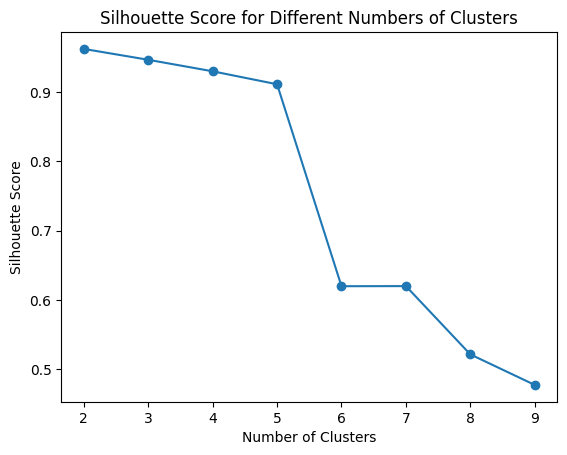

In [ ]:
import matplotlib.pyplot as plt

# Grafikon Silhouette score-a
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()
